# Topic classification for German news articles - Deep Learning

# 1. Libraries

In [24]:
import tensorflow as tf

In [25]:
tf.__version__

'2.11.0'

In [26]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Flatten
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.layers import Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from keras.regularizers import l2
import re
import csv
import spacy as sp
import pickle

# 2. Data import

In [27]:
# Import dataset and organize df
art_df = pd.read_csv('articles.csv', encoding='utf-8', delimiter=';', quotechar='\'', quoting=csv.QUOTE_MINIMAL)

# Import test data
# test_df = pd.read_csv('test.csv', encoding='utf-8', delimiter=';', quotechar='\'', quoting=csv.QUOTE_MINIMAL)

# Reset col names to first row
art_df=art_df.T.reset_index().T.reset_index(drop=True)

# Add new col names to train_df
art_df = art_df.rename(columns={0: 'cat', 1: 'text'})

# Set option to display more content in cells
pd.set_option('display.max_colwidth', 500)

art_df.head(2)

,cat,text
0,Etat,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
1,Etat,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden."


# 3. EDA and data cleaning

## 3.1 EDA

In [28]:
art_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10273 entries, 0 to 10272
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cat     10273 non-null  object
 1   text    10273 non-null  object
dtypes: object(2)
memory usage: 160.6+ KB


In [29]:
# Check count and unique
art_df.describe()

,cat,text
count,10273,10273
unique,9,10271
top,Panorama,Der Volltext dieses auf Agenturmeldungen basierenden Artikels steht aus rechtlichen Gründen nicht mehr zur Verfügung.
freq,1678,2


In [30]:
# Check for duplicates in text col -> 1
art_df["text"].duplicated().sum()

# One duplicate text, probably assigned to two different categories

2

In [31]:
# Find duplicate index
duplicated_text=art_df["text"].duplicated()
# Create df with index numbers in first col and transform the col to a list
duplicated_df = duplicated_text.loc[duplicated_text==True].to_frame().reset_index()
duplicated_list = duplicated_df["index"].tolist()
duplicated_list

[1384, 5047]

In [32]:
# Find duplicate rows based on indexlist
art_df.loc[duplicated_list,:]

,cat,text
1384,Inland,"Gemeindeergebnisse, Mandate und mögliche Koalitionen im Überblick."
5047,Panorama,Der Volltext dieses auf Agenturmeldungen basierenden Artikels steht aus rechtlichen Gründen nicht mehr zur Verfügung.


In [33]:
# Drop rows containing whose index is in duplicated_list
art_df = art_df.drop(duplicated_list)

In [34]:
# Check again for duplicates -> 0
art_df["text"].duplicated().sum()

0

In [35]:
# Check again count and unique
art_df.describe()

,cat,text
count,10271,10271
unique,9,10271
top,Panorama,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
freq,1677,1


In [36]:
# List of categories
art_df["cat"].unique().tolist()

['Etat',
 'Inland',
 'International',
 'Kultur',
 'Panorama',
 'Sport',
 'Web',
 'Wirtschaft',
 'Wissenschaft']

In [37]:
# Count articles per category
art_df["cat"].value_counts()

cat
Panorama         1677
Web              1677
International    1511
Wirtschaft       1411
Sport            1201
Inland           1014
Etat              668
Wissenschaft      573
Kultur            539
Name: count, dtype: int64

In [38]:
# Merge categories and adapt category labels
art_df.loc[art_df['cat'] == 'Web', 'cat'] = 'Tech'
art_df.loc[art_df['cat'] == 'International', 'cat'] = 'Politics'
art_df.loc[art_df['cat'] == 'Wirtschaft', 'cat'] = 'Business'
art_df.loc[art_df['cat'] == 'Inland', 'cat'] = 'Politics'
art_df.loc[art_df['cat'] == 'Etat', 'cat'] = 'Media'
art_df.loc[art_df['cat'] == 'Wissenschaft', 'cat'] = 'Science'
art_df.loc[art_df['cat'] == 'Kultur', 'cat'] = 'Entertainment & Arts'

art_df.head(2)

,cat,text
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche..."
1,Media,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden."


In [39]:
# Count articles per category again
art_df["cat"].value_counts()

cat
Politics                2525
Panorama                1677
Tech                    1677
Business                1411
Sport                   1201
Media                    668
Science                  573
Entertainment & Arts     539
Name: count, dtype: int64

In [40]:
# Add col with number of words for each article
art_df['WordCount'] = art_df['text'].str.split().str.len()
art_df.head(3)

,cat,text,WordCount
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138
1,Media,"App sei nicht so angenommen worden wie geplant. Wegen zu geringer Nutzung schaltet Spiegel Online nach zwei Jahren die Fußball-App aus, die App sei nicht so genutzt worden, wie man sich das vorgestellt habe. Dafür soll der Live-Fußball-Bereich in der News-App ausgebaut werden.",43
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001


In [41]:
random_rows = art_df.sample(n=4, replace=True)
random_rows=random_rows.loc[:,]

In [42]:
random_rows_copy=random_rows.copy()
random_rows_copy= random_rows_copy.loc[:,["cat","text"]]

random_rows_copy = random_rows_copy.rename(columns={'cat': 'Category', 'text': 'Text'})
random_rows_copy = random_rows_copy[['Text', 'Category']]
random_rows_copy

,Text,Category
4262,"Bundeskanzler und Vizekanzler schärfen ihren Ton und weisen EU-Kritik zurück. Wien – Mit scharfen Worten haben Bundeskanzler Werner Faymann (SPÖ) und Vizekanzler Reinhold Mitterlehner (ÖVP) die Kritik der EU-Kommission an Österreichs Asylobergrenzen zurückgewiesen. Die Position der Kommission sei unsinnig, sagte Faymann am Dienstag. Auf diese Art von Ratschlag können wir verzichten, polterte der Kanzler im Anschluss an den Ministerrat. Wie die EU derzeit mit den Fluchtbewegungen aus Syrien u...",Panorama
1741,"Ein Zivilist und drei Polizisten als Opfer. Mogadischu – Bei der Explosion einer Autobombe vor einer Polizeistation in Somalias Hauptstadt Mogadischu sind mindestens sechs Menschen getötet und 15 weitere verletzt worden. Ein mit Sprengstoff beladenes Fahrzeug sei am Montag in den Eingang einer Polizeiwache gerammt, sagte der Polizist Ali Hassan der Deutschen Presse-Agentur. Unter den Toten befinden sich nach Polizeiangaben drei Polizisten, zwei Angreifer und ein Zivilist. Sicherheitskräfte h...",Politics
4752,"Nachdem er die Unterbringung von Flüchtlingen zur Chefsache gemacht hat, wollte Bundeskanzler Werner Faymann seinen Vorschlag über Bezirksquoten durchbringen – ohne Erfolg. Wien – Bundeskanzler Werner Faymann (SPÖ) ist beim Asylgipfel mit den Ländern am Mittwochabend mit seinem Vorschlag einer Bezirksquote für die Flüchtlingsunterbringung abgeblitzt. Nach gut vierstündigen Beratungen war das einzige Ergebnis, dass man bis Ende Juli seitens der Länder 6.500 Plätze zur Verfügung stellen will. ...",Panorama
2112,"Pjöngjang: Seoul plant Schlag gegen die Führung. Seoul – Als Reaktion auf Militärmanöver der USA mit Südkorea verschärft Nordkorea seine Drohgebärden. Das Militär des international isolierten Landes drohte Südkorea am Samstag ultimativ mit Militärschlägen. Es warf der Regierung von Präsidentin Park Geun-hye in der von den Staatsmedien veröffentlichten Erklärung vor, einen Einsatz zum Schlag gegen die Führung in Pjöngjang geplant zu haben und diesen Plan umsetzen zu wollen. Südkorea müsse sic...",Politics


Total word count:


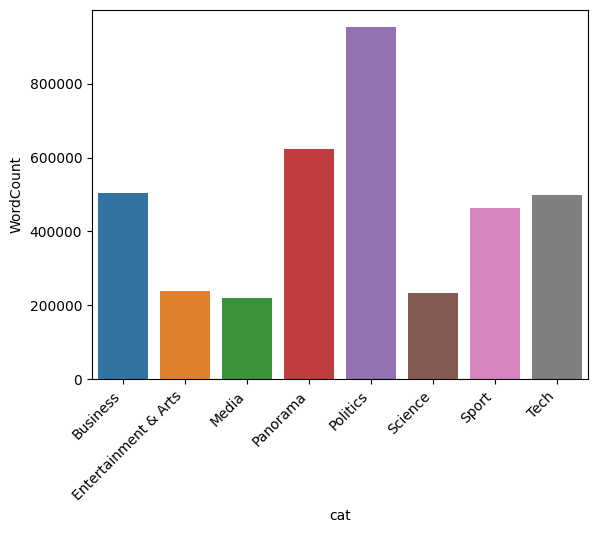

In [43]:
# Total word counts by category
counts=art_df.groupby('cat')['WordCount'].sum().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax=sns.barplot(x='cat', y='WordCount', data=counts)

# Tilt the bar labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

print("Total word count:")

plt.show()

# Display word counts by category as df
#counts

Average word count:


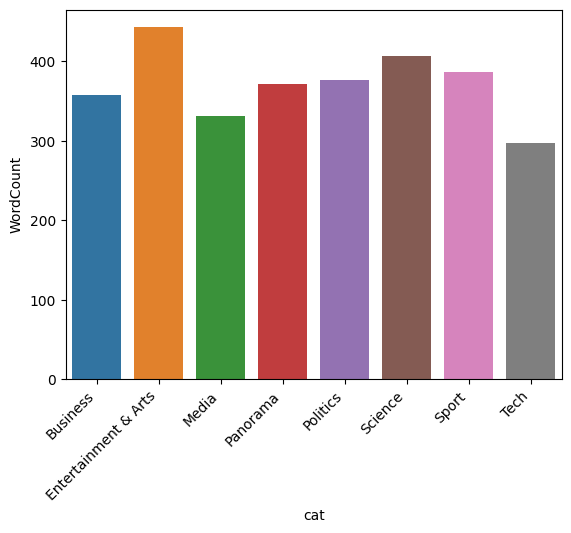

In [44]:
# Average word counts by category
avg_counts=art_df.groupby('cat')['WordCount'].mean().to_frame().reset_index()

# Barplot
import seaborn as sns
import matplotlib.pyplot as plt

ax2=sns.barplot(x='cat', y='WordCount', data=avg_counts)

# Tilt the bar labels
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

print("Average word count:")
plt.show()

In [45]:
# Description of counts by category
desc=art_df.groupby('cat')['WordCount'].describe()
desc

,count,mean,std,min,25%,50%,75%,max
cat,,,,,,,,
Business,1411.0,357.840539,229.936626,14.0,191.50,326.0,483.50,1914.0
Entertainment & Arts,539.0,442.816327,349.759814,8.0,219.00,352.0,563.00,2741.0
Media,668.0,331.175150,288.295863,12.0,154.75,247.0,438.75,2637.0
Panorama,1677.0,371.796661,255.432886,10.0,184.00,311.0,491.00,2832.0
Politics,2525.0,376.883168,272.809395,4.0,184.00,322.0,491.00,2553.0
Science,573.0,406.984293,264.641692,20.0,225.00,338.0,497.00,2238.0
Sport,1201.0,386.355537,257.235905,3.0,184.00,348.0,524.00,2411.0
Tech,1677.0,297.564699,272.331952,3.0,163.00,229.0,340.00,4800.0


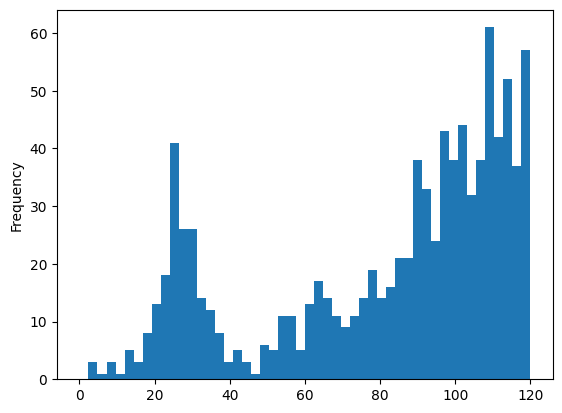

In [46]:
# Hist of WordCounts in range 0 to 120
import matplotlib.pyplot as plt
art_df['WordCount'].plot.hist(range=(0, 120), bins=50);

## 3.2 Data exclusion

In [47]:
# Remove articles with less than 47 words, as they are mostly captions
art_df=art_df.loc[art_df["WordCount"]>47,:]
art_df

,cat,text,WordCount
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001
3,Media,"Mitarbeiter überreichten Eigentümervertretern Petition gegen Personalabbau. Wien – Mehrere hundert APA-Mitarbeiter haben laut dem Betriebsrat eine Resolution unterschrieben, die am Mittwoch den Eigentümervertretern übergeben wurde. Inhalt ist ein deutlicher Protest gegen den geplanten Personalabbau (DER STANDARD berichtete) und für eine Gleichstellung der Mitarbeiter von APA-Tochterunternehmen bei automatischen Gehaltsanpassungen. Ich lehne erneute Personalkürzungen oder gar Kündigungen, wie...",250
4,Media,"Service: Jobwechsel in der Kommunikationsbranche im Überblick. Hier liefert derStandard.at/Etat Jobwechsel in der Kommunikationsbranche im Überblick. Grob sortiert nach Kalenderwochen, in denen die Infos einlangten. Quellen: Presse- und eigene Infos, andere Branchendienste wie Horizont.at und medianet.at. Wenn Sie Infos für uns haben, bitte ein Mail an etat@derstandard.at schicken. Woche 15 / 2017 Woche 14 / 2017 Woche 13 / 2017 Woche 12 / 2017 Woche 9 / 2017 Woche 8 / 2017 Woche 7 / 2017 Sp...",306
5,Media,"Was Sie über diese Woche wissen sollten - und was Sie gleich wieder vergessen können. Wien - Was hat sich diese Woche getan in der Medienwelt? Ist Ihnen da nichts entgangen? Besser noch einmal durchchecken – im Etat.at-Wochenquiz. Wir wünschen viel Spaß beim Mitmachen! Und für alle, die vorige Woche nicht so viel Zeit hatten, Medien-Nachrichten zu lesen: ein nützlicher Link.",61
...,...,...,...
10268,Science,"Die Fundstelle in Südengland ist Unesco-Weltkulturerbe, neolithische Ikone und das archäologische Monument schlechthin. Auch für Archäologen ist die Arbeit dort streng reglementiert. Als wir an einem Februartag um 5.30 Uhr mit unserem Bodenradar Mira 1 über einen Feldweg auf Stonehenge zufahren, bin ich leicht angespannt. Die Erlaubnis dafür, als erstes Team den Bereich innerhalb des Steinkreises mit motorisierten geophysikalischen Messgeräten zu untersuchen, haben wir erst am Tag davor von ...",1022
10269,Science,"Im Team arbeitet auch ein Inspektor der sudanesischen Antikenverwaltung. Gearbeitet wird sechs Tage die Woche, der Arbeitstag in Amara West beginnt um 5.50 Uhr. Woche drei im Sudan, und die Grabung kann nun wirklich beginnen. Auch das Team ist mittlerweile vollständig, es ist das gleiche wie im vergangenen Jahr: Michelle, die kanadische Anthropologin, die keine feste Anstellung hat und daher einen Großteil des Jahres auf Ausgrabungen in der Türkei, Zypern, Katar, Schottland und England verbr...",940
10270,Science,"Die zentrale Frage des Projekts: Siedelten Ägypter hierher, oder übernahmen Nubier Elemente der ägyptischen Kultur?. Woche fünf in Amara West war von mehreren außergewöhnlichen Ereignissen gekennzeichnet. Zum einen hat uns ein Magen-Darm-Virus erwischt, das abwechselnd einen Großteil des Teams kurzfristig außer Gefecht setzte. Das kommt im Durchschnitt einmal pro Kampagne vor, obwohl die hygienischen Verhältnisse im Sudan im Vergleich zu den meisten ande

In [48]:
# Info and description again
art_df.info()
art_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 10077 entries, 0 to 10272
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cat        10077 non-null  object
 1   text       10077 non-null  object
 2   WordCount  10077 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 314.9+ KB


,WordCount
count,10077.000000
mean,370.248685
std,268.794275
min,48.000000
25%,186.000000
50%,304.000000
75%,482.000000
max,4800.000000


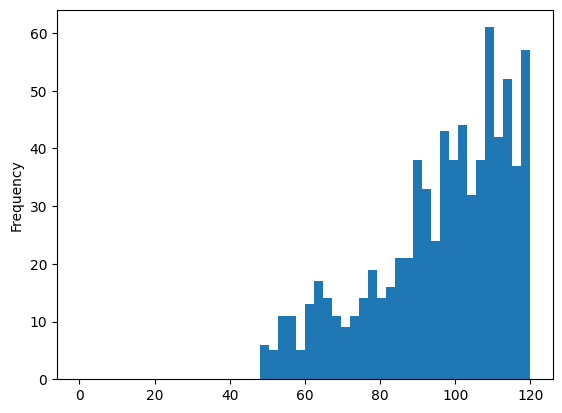

In [49]:
# Again, hist of WordCounts in range 0 to 120
import matplotlib.pyplot as plt
art_df['WordCount'].plot.hist(range=(0, 120), bins=50);

# 4. Text preprocessing

In [50]:
# Create copy of train_df to be used for text preprocessing
art_df_prep = art_df.copy()

## 4.1 Text cleaning

In [51]:
import re

# Function: remove HTML tags
def remove_html_tags(text):
    clean_text = re.sub('<.*?>', '', text)
    return clean_text

# Function: remove special characters, numbers, and punctuation
def remove_special_characters(text):
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', text)
    return clean_text

# Function: convert text to lowercase
def convert_to_lowercase(text):
    return text.lower()

# Function: remove extra whitespace
def remove_extra_whitespace(text):
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply text cleaning steps to 'text' column
art_df_prep['text_cleaned'] = art_df_prep['text'].apply(lambda x: remove_html_tags(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: remove_special_characters(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: convert_to_lowercase(x))
art_df_prep['text_cleaned'] = art_df_prep['text_cleaned'].apply(lambda x: remove_extra_whitespace(x))

art_df_prep.head(2)


,cat,text,WordCount,text_cleaned
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...


## 4.2 Lemmatization

In [52]:
# Load the German language model
nlp = sp.load("de_core_news_sm")

In [53]:
# Function: lemmatize texts/articles (runs for 5 minutes)

def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

art_df_prep["text_lemmatized"] = art_df_prep["text_cleaned"].apply(lemmatize_text)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid berichten töten sich in der Folge mehr Mensch selbst so wie damals als goeth Briefroman der leid der jung Werther ers...
3,Media,"Mitarbeiter überreichten Eigentümervertretern Petition gegen Personalabbau. Wien – Mehrere hundert APA-Mitarbeiter haben laut dem Betriebsrat eine Resolution unterschrieben, die am Mittwoch den Eigentümervertretern übergeben wurde. Inhalt ist ein deutlicher Protest gegen den geplanten Personalabbau (DER STANDARD berichtete) und für eine Gleichstellung der Mitarbeiter von APA-Tochterunternehmen bei automatischen Gehaltsanpassungen. Ich lehne erneute Personalkürzungen oder gar Kündigungen, wie...",250,mitarbeiter überreichten eigentümervertretern petition gegen personalabbau wien mehrere hundert apamitarbeiter haben laut dem betriebsrat eine resolution unterschrieben die am mittwoch den eigentümervertretern übergeben wurde inhalt ist ein deutlicher protest gegen den geplanten personalabbau der standard berichtete und für eine gleichstellung der mitarbeiter von apatochterunternehmen bei automatischen 

## 4.3 Character replacement

In [54]:
# Define a dictionary for character replacement
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

# Function to replace characters in a string
def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

# Apply character replacement to the 'Text' column
art_df_prep['text_replaced'] = art_df_prep['text_lemmatized'].apply(replace_characters)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized,text_replaced
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der fuer der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr G...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid berichten töten sich in der Folge mehr Mensch selbst so wie damals als goeth Briefroman der leid der jung Werther ers...,zu Welttag der Suizidpraevention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel fuehren zu nachahmungen und wer ueber Suizidalitaet dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefaehrlich als Nichtwissen werthereffekt ja ja schon mal hoeren werden ueber ein Suizid berichten toeten sic

## 4.4 Stopword removal

In [55]:
nlp = sp.load('de_core_news_sm')

In [56]:
# Function for stopword removal
def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

# Call function, adding a new col to df
art_df_prep['text_stopwords_removed'] = art_df_prep['text_lemmatized'].apply(remove_stopwords)

art_df_prep.head(3)

,cat,text,WordCount,text_cleaned,text_lemmatized,text_replaced,text_stopwords_removed
0,Media,"Die ARD-Tochter Degeto hat sich verpflichtet, ab August einer Quotenregelung zu folgen, die für die Gleichstellung von Regisseurinnen sorgen soll. In mindestens 20 Prozent der Filme, die die ARD-Tochter Degeto produziert oder mitfinanziert, sollen ab Mitte August Frauen Regie führen. Degeto-Chefin Christine Strobl folgt mit dieser Selbstverpflichtung der Forderung von Pro Quote Regie. Die Vereinigung von Regisseurinnen hatte im vergangenen Jahr eine Quotenregelung gefordert, um den weibliche...",138,die ardtochter degeto hat sich verpflichtet ab august einer quotenregelung zu folgen die für die gleichstellung von regisseurinnen sorgen soll in mindestens prozent der filme die die ardtochter degeto produziert oder mitfinanziert sollen ab mitte august frauen regie führen degetochefin christine strobl folgt mit dieser selbstverpflichtung der forderung von pro quote regie die vereinigung von regisseurinnen hatte im vergangenen jahr eine quotenregelung gefordert um den weiblichen filmschaffen...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der für der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie führen degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr Geh...,der Ardtochter Degeto haben sich verpflichten ab August ein quotenregelung zu folgen der fuer der Gleichstellung von Regisseurinn sorgen sollen in mindestens Prozent der Film der der Ardtochter Degeto produzieren oder mitfinanzieren sollen ab Mitte August Frau Regie fuehren degetochefin Christine Strobl folgen mit dieser Selbstverpflichtung der Forderung von pro quot Regie der Vereinigung von Regisseurinn haben in vergangen Jahr ein Quotenregelung fordern um der weiblich Filmschaffend mehr G...,Ardtochter Degeto verpflichten August quotenregelung folgen Gleichstellung Regisseurinn sorgen mindestens Prozent Film Ardtochter Degeto produzieren mitfinanzieren Mitte August Frau Regie führen degetochefin Christine Strobl folgen Selbstverpflichtung Forderung pro quot Regie Vereinigung Regisseurinn vergangen Quotenregelung fordern weiblich Filmschaffend Gehör ökonomisch Gleichstellung verschaffen pro quot Regie kritisieren Prozent regiestudierende weiblich Anteil Regisseurinn Fernsehfilm P...
2,Media,"Zum Welttag der Suizidprävention ist es Zeit, das alte Dogma ""Über Suizide schreibt man nicht"" zu verwerfen. Denn erst Ausnahmen von dieser Regel führen zu Nachahmungen – und wer über Suizidalität dann schweigt, wenn sie nicht sensationell ist, stigmatisiert die Betroffenen weiter. Halbwissen ist oft gefährlicher als Nichtwissen. Werther-Effekt? Ja ja, schon mal gehört: Wird über einen Suizid berichtet, töten sich in der Folge mehr Menschen selbst. So wie damals, als Goethes Briefroman Die L...",1001,zum welttag der suizidprävention ist es zeit das alte dogma ber suizide schreibt man nicht zu verwerfen denn erst ausnahmen von dieser regel führen zu nachahmungen und wer über suizidalität dann schweigt wenn sie nicht sensationell ist stigmatisiert die betroffenen weiter halbwissen ist oft gefährlicher als nichtwissen werthereffekt ja ja schon mal gehört wird über einen suizid berichtet töten sich in der folge mehr menschen selbst so wie damals als goethes briefroman die leiden des jungen w...,zu Welttag der Suizidprävention sein es Zeit der alt Dogma ber Suizide schreiben man nicht zu verwerfen denn erst Ausnahme von dieser Regel führen zu nachahmungen und wer über Suizidalität dann schweigen wenn sie nicht sensationell sein stigmatisieren der Betroffen weiter halbwissen sein oft gefährlich als Nichtwissen werthereffekt ja ja schon mal hören werden über ein Suizid beri

## 4.5 Tokenization and padding

In [57]:
# Initialize the tokenizer
# (with 5000 most common words in 'text' column as vocabulary)
tokenizer = Tokenizer(num_words=30000, oov_token="<OOV>")

In [58]:
# Fit the tokenizer on our sentences
tokenizer.fit_on_texts(art_df_prep['text_stopwords_removed'].values)

In [59]:
# Get the word index (dictionary of words and their unique integer representations)
word_index = tokenizer.word_index

In [60]:
# Convert our sentences to sequences of integers
sequences = tokenizer.texts_to_sequences(art_df_prep['text_stopwords_removed'].values)

In [61]:
word_index = tokenizer.word_index

In [62]:
# Pad the sequences so that they are all the same length 
# (data is X)
data = pad_sequences(sequences, maxlen=600)

In [63]:
# Convert labels to integers 
# (labels are y)
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(art_df_prep['cat'])

# 5. Train-test split

In [64]:
# Copy df before further processing
art_df_split = art_df_prep.copy()

## 5.1 Remove columns

In [65]:
# Remove col not required
art_df_split = art_df_split[['cat', 'text_stopwords_removed']]
art_df_split.head(2)

,cat,text_stopwords_removed
0,Media,Ardtochter Degeto verpflichten August quotenregelung folgen Gleichstellung Regisseurinn sorgen mindestens Prozent Film Ardtochter Degeto produzieren mitfinanzieren Mitte August Frau Regie führen degetochefin Christine Strobl folgen Selbstverpflichtung Forderung pro quot Regie Vereinigung Regisseurinn vergangen Quotenregelung fordern weiblich Filmschaffend Gehör ökonomisch Gleichstellung verschaffen pro quot Regie kritisieren Prozent regiestudierende weiblich Anteil Regisseurinn Fernsehfilm P...
2,Media,Welttag Suizidprävention alt Dogma ber Suizide schreiben verwerfen Ausnahme Regel führen nachahmungen Suizidalität schweigen sensationell stigmatisieren Betroffen halbwissen gefährlich Nichtwissen werthereffekt mal hören Suizid berichten töten Folge Mensch goeth Briefroman leid jung Werther erscheinen ber Suizide berichten stimmen fast September Welttag Suizidprävention Suizide verhinden Journalist Verantwortung wahrnehmen bedeuten Fall alt Stehsatz ber Suizide schreiben verabschieden Dogma ...


## 5.2 Split

In [67]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42) # , stratify=y


# 6. Encoding of y

In [68]:
# Convert the labels to one-hot encoding
num_classes = np.max(labels) + 1
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# 7. Model

## 7.1 Definition and training

In [69]:
# Define the model
model = Sequential()
model.add(Embedding(30000, 64, input_length=600))
model.add(Flatten())
model.add(Dense(128, activation='relu')) # here neurons (currently 128) can be reduced
model.add(Dropout(0.1))
#model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.001), bias_regularizer=l2(0.001)))
model.add(Dense(num_classes, activation='softmax'))

2023-06-06 16:00:45.992241: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [70]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [71]:
# Train the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=60)

Epoch 1/10
135/135 [==============================] - 23s 159ms/step - loss: 1.6426 - accuracy: 0.4039 - val_loss: 1.0840 - val_accuracy: 0.6071
Epoch 2/10
135/135 [==============================] - 18s 134ms/step - loss: 0.4767 - accuracy: 0.8649 - val_loss: 0.5880 - val_accuracy: 0.8150
Epoch 3/10
135/135 [==============================] - 18s 132ms/step - loss: 0.0651 - accuracy: 0.9900 - val_loss: 0.5817 - val_accuracy: 0.8155
Epoch 4/10
135/135 [==============================] - 21s 159ms/step - loss: 0.0148 - accuracy: 0.9990 - val_loss: 0.5953 - val_accuracy: 0.8175
Epoch 5/10
135/135 [==============================] - 22s 162ms/step - loss: 0.0055 - accuracy: 0.9998 - val_loss: 0.6180 - val_accuracy: 0.8110
Epoch 6/10
135/135 [==============================] - 25s 182ms/step - loss: 0.0037 - accuracy: 0.9998 - val_loss: 0.6364 - val_accuracy: 0.8170
Epoch 7/10
135/135 [==============================] - 19s 142ms/step - loss: 0.0032 - accuracy: 0.9995 - val_loss: 0.6524 - val_ac

In [72]:
#  Get predictions for test set
predictions = np.argmax(model.predict(X_test), axis=-1) 

63/63 [==============================] - 1s 12ms/step


## 7.2 Accuracy

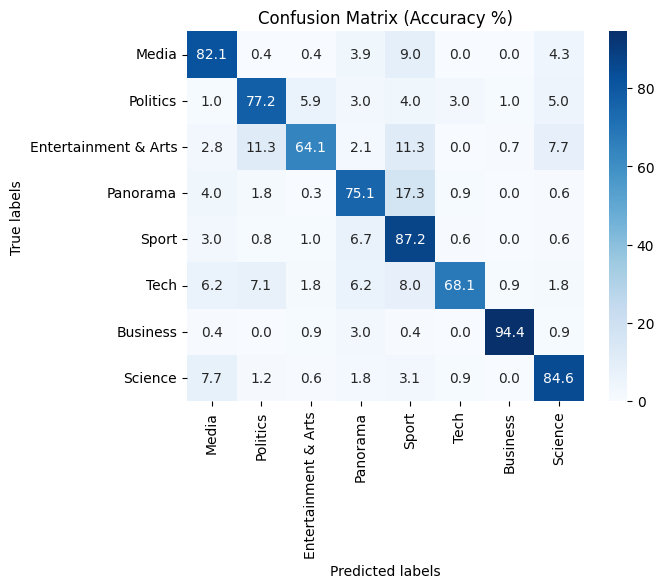

In [73]:
# Confusion matrix for accuracy

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming you have true labels and predicted labels for your test data
true_labels = np.argmax(y_test, axis=1) # backtransform y_test from OHE format
predicted_labels = predictions

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Create a list of class labels (optional, if you have class labels)
class_labels = art_df["cat"].unique().tolist()  # List of class labels in the order of the confusion matrix

# Create a heatmap using seaborn
sns.heatmap(cm_norm, annot=True, cmap='Blues', fmt='.1f')

# Add labels, title, and axis ticks
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Accuracy %)')
plt.xticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, class_labels, rotation=0)

# Create tick labels with class names
tick_labels = class_labels
#tick_labels = [f'{class_labels[i]} ({i})' for i in range(len(class_labels))]
plt.xticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=90)
plt.yticks(np.arange(len(class_labels)) + 0.5, tick_labels, rotation=0)

# Display the plot
plt.show()


## 7.3 Exportation

In [ ]:
# Save trained model to file

with open('de_class_dl_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# 8. Input classification

In [ ]:
# Open model from file
with open('de_class_dl_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [77]:
# Load spaCy model for German
nlp = sp.load('de_core_news_sm')

# Your input text
input_text = input("Enter text: ")

# Clean input text
def preprocess_text_clean(text):
    clean_text = re.sub('<.*?>', '', text) # Remove HTML tags
    clean_text = re.sub(r'[^a-zA-Z\sßüöä]', '', clean_text) # remove special characters, numbers, and punctuation
    clean_text = clean_text.lower() # lowercasing
    clean_text = re.sub(r'\s+', ' ', clean_text) # remove extra whitespace
    return clean_text.strip()

#Lemmatize input text
def lemmatize_text(text):
    doc = nlp(text)
    lemmas = [token.lemma_ for token in doc]
    #return lemmas
    return ' '.join(lemmas)

# Replace characters of input text based on dict
character_replacements = {
    'ä': 'ae',
    'ö': 'oe',
    'ü': 'ue',
    'ß': 'ss'
}

def replace_characters(text):
    for old_char, new_char in character_replacements.items():
        text = text.replace(old_char, new_char)
    return text

def remove_stopwords(text):
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop]
    #return tokens
    return ' '.join(tokens)

processed_text = preprocess_text_clean(input_text)
processed_text = lemmatize_text(processed_text)
processed_text = replace_characters(processed_text)
processed_text = remove_stopwords(processed_text)

# Tokenize the text
input_sequence = tokenizer.texts_to_sequences([processed_text])

# Pad the sequence
padded_input_sequence = pad_sequences(input_sequence, maxlen=600)

# Predict the topic
prediction = model.predict(padded_input_sequence)

# Find the topic with the highest predicted probability
predicted_topic = np.argmax(prediction[0])

# Convert the topic from an integer back to the original category name
predicted_topic_name = label_encoder.inverse_transform([predicted_topic])

# Print classification
print(f'\nTopic: {predicted_topic_name[0]}')

# Get sorted list of categories
my_list=art_df["cat"].unique().tolist()
my_list = sorted(my_list)

# Create dict for storing category-score pairs (pos. scores only)
topic_dict = {}

#prediction_list = prediction[0].tolist()
#print(prediction_list)

# Assign classifications with positive confidence scores to dict
for category, score in zip(my_list,  prediction[0].tolist()):
    #print(category, ": ", round(score, 3))
    if score > 0:
        topic_dict[category] = round(score, 3)
topic_dict_sorted = sorted(topic_dict.items(), key=lambda item: item[1], reverse=True)

# Print score for each category
print ('-'*50)
for entry in topic_dict_sorted:
    
    print (f'{entry[0]}: {entry[1]}')



Enter text:  Olaf scholz ist bundeskanzler


1/1 [==============================] - 0s 107ms/step

Topic: Tech
--------------------------------------------------
Tech: 0.408
Media: 0.248
Sport: 0.098
Business: 0.084
Panorama: 0.074
Politics: 0.056
Entertainment & Arts: 0.022
Science: 0.009
